In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [22]:
df_condiciones = pd.read_csv('datos/condiciones_climaticas.csv')
df_condiciones.head()

,anio,codigo_iso,dias_con_heladas,eventos_extremos,humedad_relativa_promedio,indice_aridez,meses_estres_hidrico,pais,precipitacion_total,region_nombre,temperatura_maxima,temperatura_minima,temperatura_promedio
0,2011,ARG,19,NaN,64,17.26,1,Argentina,1050,Pampa Húmeda,22.3,3.6,16.9
1,2011,ARG,48,NaN,82,8.63,6,Argentina,702,Cuyo,34.6,8.5,22.6
2,2011,ARG,86,NaN,61,18.37,7,Argentina,635,Patagonia,21.5,2.1,9.6
3,2011,AUS,49,NaN,59,12.24,0,Australia,1040,Murray-Darling Basin,33.9,18.1,23.6
4,2011,AUS,100,inundacion,82,10.64,1,Australia,912,Queensland Coast,34.5,9.3,23.8


In [23]:
df_politicas = pd.read_csv('datos/politicas_agricolas.csv')
df_politicas.head()

,codigo,nombre_pais,acuerdo_internacional_anio_firma,acuerdo_internacional_firmado,acuerdo_internacional_nombre,regulacion_anio_implementacion,regulacion_multa_hectarea,regulacion_porcentaje_minimo,regulacion_tipo,regulacion_vigente,subsidio_anio,subsidio_beneficiarios,subsidio_descripcion,subsidio_moneda,subsidio_monto,subsidio_Precio_euros,subsidio_tipo
0,ARG,Argentina,NaN,0,Convenio_Biodiversidad,2010,NaN,NaN,pesticidas_neonicotinoides,1,2019,7215,Subsidio para investigacion desarrollo,USD,15562206,14317229.52,investigacion_desarrollo
1,ARG,Argentina,NaN,0,Convenio_Biodiversidad,2010,NaN,NaN,pesticidas_neonicotinoides,1,2021,1914,Subsidio para maquinaria,USD,25542386,23498995.12,maquinaria
2,ARG,Argentina,NaN,0,Convenio_Biodiversidad,2010,NaN,NaN,pesticidas_neonicotinoides,1,2021,10823,Subsidio para fertilizantes,USD,32694726,30079147.92,fertilizantes
3,ARG,Argentina,NaN,0,Convenio_Biodiversidad,2010,NaN,NaN,pesticidas_neonicotinoides,1,2023,10898,Subsidio para expansion frontera agricola,USD,12595066,11587460.72,expansion_frontera_agricola
4,ARG,Argentina,NaN,0,Convenio_Biodiversidad,2012,NaN,NaN,uso_agua,0,2019,7215,Subsidio para investigacion desarrollo,USD,15562206,14317229.52,investigacion_desarrollo


In [24]:
#Valores nulos que existen
df_condiciones.isnull().sum()

anio                           0
codigo_iso                     0
dias_con_heladas               0
eventos_extremos             142
humedad_relativa_promedio      0
indice_aridez                  0
meses_estres_hidrico           0
pais                           0
precipitacion_total            0
region_nombre                  0
temperatura_maxima             0
temperatura_minima             0
temperatura_promedio           0
dtype: int64

En este caso la lectura de los nulos es correcta ya que en todas las condiciones climaticas no hay eventos extremos.

In [25]:
df_politicas.isnull().sum()

codigo                                0
nombre_pais                           0
acuerdo_internacional_anio_firma     64
acuerdo_internacional_firmado         0
acuerdo_internacional_nombre          0
regulacion_anio_implementacion        0
regulacion_multa_hectarea           135
regulacion_porcentaje_minimo        136
regulacion_tipo                       0
regulacion_vigente                    0
subsidio_anio                         0
subsidio_beneficiarios                0
subsidio_descripcion                  0
subsidio_moneda                       0
subsidio_monto                        0
subsidio_Precio_euros                 0
subsidio_tipo                         0
dtype: int64

Estos nulos son completamente normales ya que no todos los acuerdos estan firmados y por eso no presentan un año de firma y en el caso de la multa, no todos conllevan una sancion o un minimo de sancion

In [26]:
df_condiciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   anio                       260 non-null    int64  
 1   codigo_iso                 260 non-null    object 
 2   dias_con_heladas           260 non-null    int64  
 3   eventos_extremos           118 non-null    object 
 4   humedad_relativa_promedio  260 non-null    int64  
 5   indice_aridez              260 non-null    float64
 6   meses_estres_hidrico       260 non-null    int64  
 7   pais                       260 non-null    object 
 8   precipitacion_total        260 non-null    int64  
 9   region_nombre              260 non-null    object 
 10  temperatura_maxima         260 non-null    float64
 11  temperatura_minima         260 non-null    float64
 12  temperatura_promedio       260 non-null    float64
dtypes: float64(4), int64(5), object(4)
memory usage: 2

## Análisis de eventos extremos

### Frecuencia de eventos extremos por pais

In [27]:
# Rellenar nulos
df_condiciones["eventos_extremos"] = df_condiciones["eventos_extremos"].fillna("")

In [28]:
# Convertir a lista 
df_condiciones["eventos_extremos"] = df_condiciones["eventos_extremos"].apply(
    lambda x: x.replace("[", "").replace("]", "").replace("'", "").split(",")
)

In [29]:
df_condiciones["num_eventos"] = df_condiciones["eventos_extremos"].apply(len)

In [30]:
lista_eventos = []

for eventos in df_condiciones["eventos_extremos"]:
    for e in eventos:
        if e != "":
            lista_eventos.append(e)

df_eventos = pd.Series(lista_eventos).value_counts()

df_eventos

sequia_severa      19
sequia_extrema     17
helada_tardia      16
tormenta_severa    13
ola_calor          12
inundacion         11
incendios          11
sequia_moderada    11
granizo             8
Name: count, dtype: int64

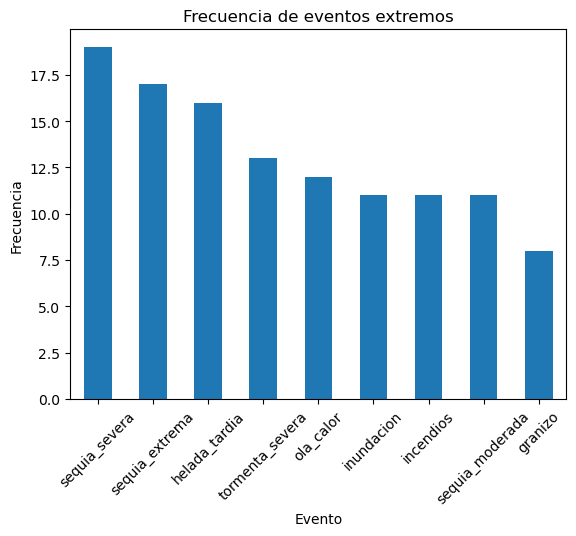

In [31]:
df_eventos.plot(kind="bar")
plt.title("Frecuencia de eventos extremos")
plt.xlabel("Evento")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

In [32]:
df_exploded = df_condiciones.explode("eventos_extremos")

df_exploded = df_exploded[df_exploded["eventos_extremos"] != ""]

eventos_pais = df_exploded.groupby(["pais", "eventos_extremos"]).size().unstack(fill_value=0)

eventos_pais

eventos_extremos,granizo,helada_tardia,incendios,inundacion,ola_calor,sequia_extrema,sequia_moderada,sequia_severa,tormenta_severa
pais,,,,,,,,,
Alemania,0,0,0,0,1,0,0,1,0
Argentina,1,3,1,0,3,2,1,2,0
Australia,0,2,2,4,2,3,0,4,2
Brasil,0,2,3,1,0,4,1,2,3
China,0,1,0,1,0,0,0,1,2
Estados Unidos,2,2,2,1,2,3,1,2,3
Francia,0,1,0,0,1,0,2,0,1
India,3,3,2,3,1,3,5,3,2
Kenia,2,2,0,1,1,1,0,4,0


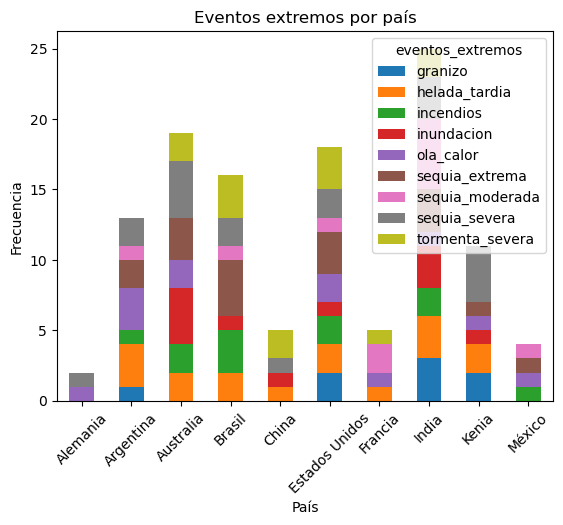

In [33]:
eventos_pais.plot(kind="bar", stacked=True)
plt.title("Eventos extremos por país")
plt.xlabel("País")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

El análisis por país muestra una distribución desigual de eventos extremos. Países como India y Australia presentan una mayor frecuencia, lo que sugiere una mayor exposición a condiciones climáticas adversas.

Por otro lado, países como Francia o China muestran menor incidencia de eventos extremos.

En cuanto al tipo de eventos, predominan las sequías (en sus distintas intensidades) y las tormentas severas, lo que refuerza la importancia del estrés hídrico como factor clave en el sistema agrícola.

In [34]:
corr = df_condiciones[[
    "indice_aridez",
    "meses_estres_hidrico",
    "precipitacion_total"
]].corr()

corr

,indice_aridez,meses_estres_hidrico,precipitacion_total
indice_aridez,1.000000,-0.606511,0.793797
meses_estres_hidrico,-0.606511,1.000000,-0.730566
precipitacion_total,0.793797,-0.730566,1.000000


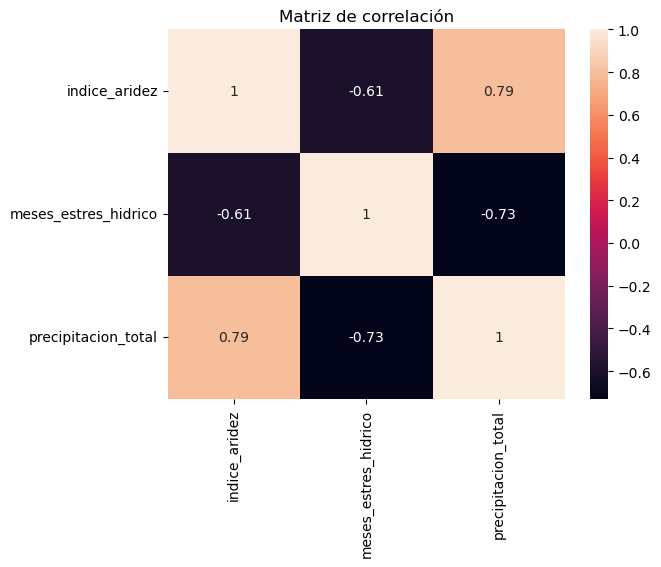

In [35]:
sns.heatmap(corr, annot=True)
plt.title("Matriz de correlación")
plt.show()

Se observa una fuerte ***correlación positiva*** (0.79) entre la precipitación total y el índice de aridez, lo que indica que a mayor precipitación, mejores condiciones hídricas en el suelo.

Por otro lado, existe una ***correlación negativa significativa*** (-0.73) entre la precipitación total y los meses de estrés hídrico, lo que confirma que menores niveles de lluvia están asociados con periodos más prolongados de escasez de agua.

Además, el índice de aridez presenta una ***correlación negativa moderada*** (-0.61) con los meses de estrés hídrico, reforzando la relación entre disponibilidad de agua y condiciones climáticas adversas.

- **Conclusion**:

La alta frecuencia de eventos relacionados con sequías observada en los datos se alinea con las correlaciones obtenidas, donde la baja precipitación está directamente asociada con mayores periodos de estrés hídrico.

Esto sugiere que las regiones con menor disponibilidad de agua no solo presentan peores indicadores climáticos, sino también una mayor vulnerabilidad a eventos extremos.


### Impacto de políticas en producción

In [46]:
df_produccion = pd.read_csv("datos/produccion_agricola.csv")

df_produccion.head()

,pais,codigo_iso,region,cultivo,anio,superficie_hectareas,rendimiento_ton_ha,produccion_ton,fertilizantes_kg_ha,agua_riego_m3_ha,tendencia_5_anios
0,Argentina,ARG,América del Sur,Soja,2011,4703643,2.22,10465461,105,4811,0.000536
1,Argentina,ARG,América del Sur,Maíz,2011,3371781,8.45,28485921,164,5557,0.030943
2,Argentina,ARG,América del Sur,Cebada,2011,1661577,2.77,4596917,105,6514,-0.039779
3,Argentina,ARG,América del Sur,Té,2011,188518,3.07,577886,236,8527,0.003623
4,Argentina,ARG,América del Sur,Algodón,2011,1638327,1.18,1929756,276,6925,0.007735


In [47]:
df_produccion.columns

Index(['pais', 'codigo_iso', 'region', 'cultivo', 'anio',
       'superficie_hectareas', 'rendimiento_ton_ha', 'produccion_ton',
       'fertilizantes_kg_ha', 'agua_riego_m3_ha', 'tendencia_5_anios'],
      dtype='object')

In [49]:
produccion_pais = df_produccion.groupby("pais")[[
    "produccion_ton",
    "rendimiento_ton_ha"
]].mean().reset_index()

produccion_pais

,pais,produccion_ton,rendimiento_ton_ha
0,Alemania,4.843421e+07,15.690500
1,Argentina,9.005145e+06,3.447750
2,Australia,7.651199e+07,15.902875
3,Brasil,7.733565e+07,14.666375
4,Canadá,9.482026e+06,3.461125
5,China,7.411340e+07,13.980250
6,España,6.273694e+07,13.182875
7,Estados Unidos,4.952174e+07,13.900125
8,Francia,5.016059e+07,12.315625
9,India,5.709305e+07,13.950000


In [50]:
politicas_pais = df_politicas.groupby("pais").size().reset_index(name="num_politicas")

In [51]:
df_final = pd.merge(produccion_pais, politicas_pais, on="pais", how="inner")

df_final

,pais,produccion_ton,rendimiento_ton_ha,num_politicas
0,Alemania,4.843421e+07,15.690500,18
1,Argentina,9.005145e+06,3.447750,12
2,Australia,7.651199e+07,15.902875,12
3,Brasil,7.733565e+07,14.666375,27
4,China,7.411340e+07,13.980250,9
5,España,6.273694e+07,13.182875,6
6,Estados Unidos,4.952174e+07,13.900125,12
7,Francia,5.016059e+07,12.315625,24
8,India,5.709305e+07,13.950000,12
9,Kenia,5.331351e+07,13.896500,6


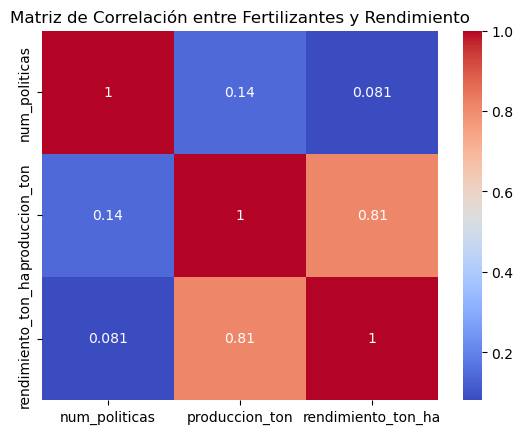

In [59]:
correlation_matrix = df_final[["num_politicas", "produccion_ton", "rendimiento_ton_ha"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación entre Fertilizantes y Rendimiento')
plt.show()

Los resultados muestran una correlación **positiva débil** entre el número de políticas y la producción total (0.14), así como con el rendimiento agrícola (0.08).

Esto indica que, aunque existe cierta relación, el número de políticas no es un factor determinante en el aumento de la producción o del rendimiento.

Por otro lado, se observa una **fuerte correlación** entre la producción total y el rendimiento (0.81), lo que confirma la coherencia de los datos y la relación directa entre ambas variables.

- **Conclusion**:

En conjunto, los resultados sugieren que las políticas agrícolas no tienen un impacto directo significativo en la producción, al menos en términos agregados por país.

Esto puede deberse a que la producción agrícola depende de múltiples factores adicionales, como las condiciones climáticas, el tipo de cultivo o el nivel tecnológico.

Por tanto, las políticas podrían estar orientadas más a la gestión y estabilización del sistema agrícola que a un aumento inmediato de la producción.

## Integración contextual


### Combinar políticas con datos de producción

In [62]:
# Total de ayudas económicas por país
subsidios_pais = df_politicas.groupby("pais")["subsidio_Precio_euros"].sum().reset_index()

subsidios_pais

,pais,subsidio_Precio_euros
0,Alemania,3.748127e+08
1,Argentina,2.384485e+08
2,Australia,2.136785e+08
3,Brasil,6.194276e+08
4,China,2.284530e+08
5,España,1.664452e+08
6,Estados Unidos,1.612560e+08
7,Francia,2.648442e+08
8,India,2.522220e+08
9,Kenia,1.598452e+08


In [63]:
produccion_pais = df_produccion.groupby("pais")[[
    "produccion_ton",
    "rendimiento_ton_ha"
]].mean().reset_index()

In [64]:
df_subsidios = pd.merge(produccion_pais, subsidios_pais, on="pais", how="inner")

df_subsidios

,pais,produccion_ton,rendimiento_ton_ha,subsidio_Precio_euros
0,Alemania,4.843421e+07,15.690500,3.748127e+08
1,Argentina,9.005145e+06,3.447750,2.384485e+08
2,Australia,7.651199e+07,15.902875,2.136785e+08
3,Brasil,7.733565e+07,14.666375,6.194276e+08
4,China,7.411340e+07,13.980250,2.284530e+08
5,España,6.273694e+07,13.182875,1.664452e+08
6,Estados Unidos,4.952174e+07,13.900125,1.612560e+08
7,Francia,5.016059e+07,12.315625,2.648442e+08
8,India,5.709305e+07,13.950000,2.522220e+08
9,Kenia,5.331351e+07,13.896500,1.598452e+08


El dataset resultante permite analizar de forma conjunta variables económicas (políticas) y productivas, facilitando la identificación de patrones y posibles relaciones entre ambas dimensiones.

### Relacionar subsidios con incrementos de rendimiento

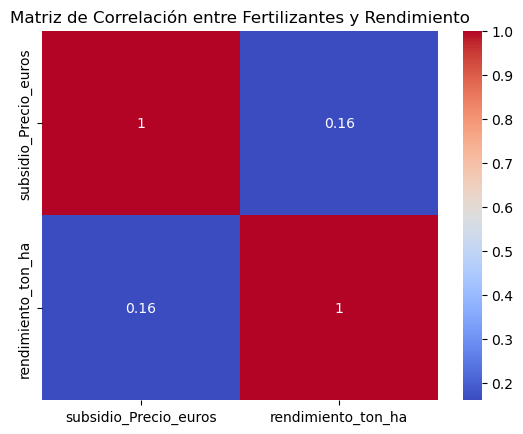

In [67]:
correlation_matrix = df_subsidios[["subsidio_Precio_euros", "rendimiento_ton_ha"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación entre Fertilizantes y Rendimiento')
plt.show()

Los resultados muestran una **correlación débil** (0.16) entre el volumen de subsidios y el rendimiento agrícola, lo que indica que una mayor inversión económica no implica necesariamente un incremento proporcional en la productividad.

Esto sugiere que los subsidios, aunque importantes, no son el único factor determinante del rendimiento agrícola, ya que este depende también de condiciones climáticas, tecnología y gestión agrícola.